# Dataset V3 Explainable AI and SHAP Analysis

This notebook explains predictions from the final Dataset V3 XGBoost model using SHAP.

The model uses NDVI, NDBI, Elevation, Population, and one-hot encoded ESA WorldCover land-cover classes. Latitude and Longitude are excluded from model features and are used only for mapping and spatial grouping.

In [1]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt

# Load Dataset V3 model-ready data
df_shap_v3 = pd.read_csv("../data/processed/model_ready_uhi_v3.csv")

# Load final V3 XGBoost model
final_xgb_v3 = joblib.load(
    "../outputs/models/xgboost_v3_landcover_model.pkl"
)

# Load exact feature order
feature_order_v3 = pd.read_csv(
    "../outputs/models/xgboost_v3_feature_order.csv"
)["Feature"].tolist()

X_shap_v3 = df_shap_v3[feature_order_v3]

print("Dataset loaded:", df_shap_v3.shape)
print("Model features:", len(feature_order_v3))
print(feature_order_v3)

Dataset loaded: (9893, 14)
Model features: 11
['NDVI', 'NDBI', 'Elevation', 'Population', 'LandCover_Bare_sparse_vegetation', 'LandCover_Built-up land', 'LandCover_Cropland', 'LandCover_Grassland', 'LandCover_Permanent_water_bodies', 'LandCover_Shrubland', 'LandCover_Tree cover']


In [2]:
try:
    import shap
    print("SHAP is already installed.")
except ImportError:
    !pip install shap
    import shap
    print("SHAP installed successfully.")

SHAP is already installed.


In [3]:
# Use a fixed sample to keep SHAP fast and reproducible
sample_size = min(1000, len(X_shap_v3))

X_shap_sample = X_shap_v3.sample(
    n=sample_size,
    random_state=42
)

print("SHAP sample size:", X_shap_sample.shape)

SHAP sample size: (1000, 11)


In [4]:
explainer_v3 = shap.TreeExplainer(final_xgb_v3)

shap_values_v3 = explainer_v3.shap_values(X_shap_sample)

print("SHAP values created successfully.")
print("SHAP values shape:", np.array(shap_values_v3).shape)

SHAP values created successfully.
SHAP values shape: (1000, 11)


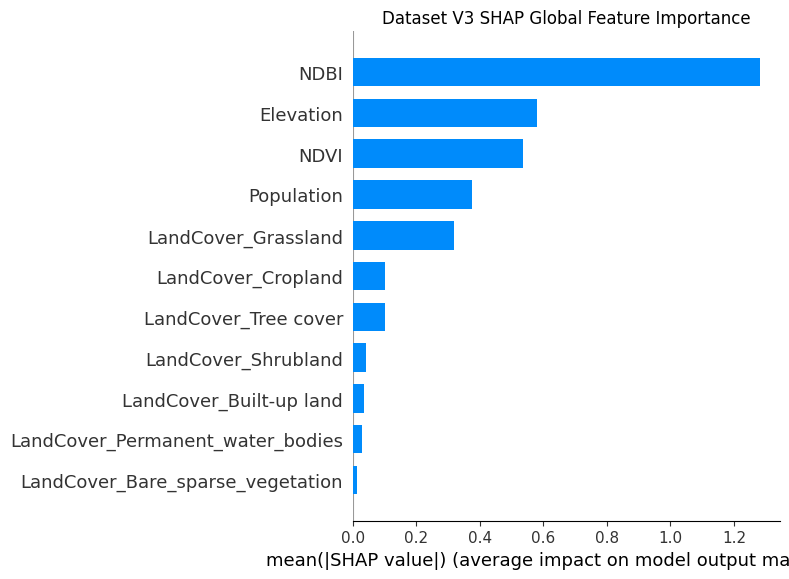

In [5]:
shap.summary_plot(
    shap_values_v3,
    X_shap_sample,
    plot_type="bar",
    show=False
)

plt.title("Dataset V3 SHAP Global Feature Importance")
plt.tight_layout()
plt.show()

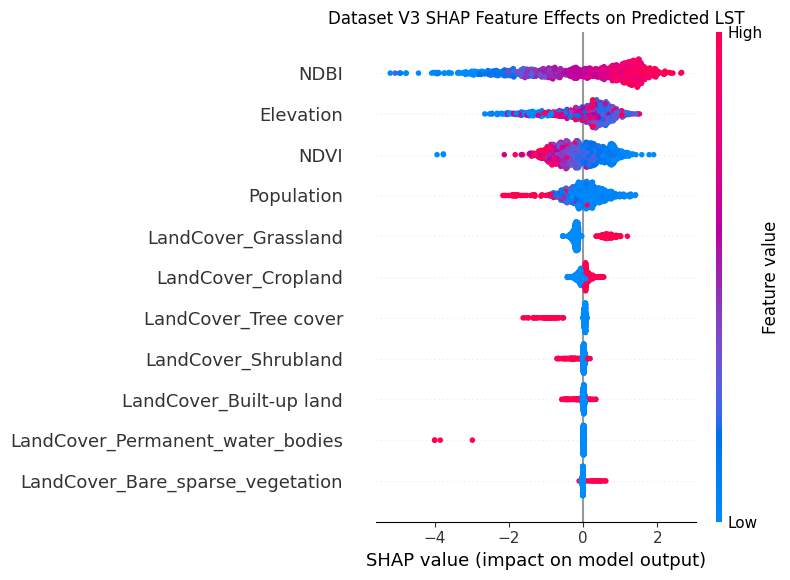

In [6]:
shap.summary_plot(
    shap_values_v3,
    X_shap_sample,
    show=False
)

plt.title("Dataset V3 SHAP Feature Effects on Predicted LST")
plt.tight_layout()
plt.show()

In [7]:
shap_importance_v3 = pd.DataFrame({
    "Feature": feature_order_v3,
    "Mean_Absolute_SHAP": np.abs(shap_values_v3).mean(axis=0)
})

shap_importance_v3 = shap_importance_v3.sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

shap_importance_v3

,Feature,Mean_Absolute_SHAP
0,NDBI,1.281032
1,Elevation,0.580169
2,NDVI,0.534977
3,Population,0.376957
4,LandCover_Grassland,0.320300
5,LandCover_Cropland,0.103129
6,LandCover_Tree cover,0.100840
7,LandCover_Shrubland,0.040502
8,LandCover_Built-up land,0.036793
9,LandCover_Permanent_water_bodies,0.029068


In [8]:
feature_name_map = {
    "NDVI": "NDVI",
    "NDBI": "NDBI",
    "Elevation": "Elevation",
    "Population": "Population",
    "LandCover_Bare_sparse_vegetation": "Land cover: Bare/sparse vegetation",
    "LandCover_Built-up_land": "Land cover: Built-up land",
    "LandCover_Cropland": "Land cover: Cropland",
    "LandCover_Grassland": "Land cover: Grassland",
    "LandCover_Permanent_water_bodies": "Land cover: Permanent water bodies",
    "LandCover_Shrubland": "Land cover: Shrubland",
    "LandCover_Tree_cover": "Land cover: Tree cover"
}

shap_importance_v3["Readable_Feature"] = (
    shap_importance_v3["Feature"].map(feature_name_map)
)

shap_importance_v3[
    ["Readable_Feature", "Mean_Absolute_SHAP"]
]

,Readable_Feature,Mean_Absolute_SHAP
0,NDBI,1.281032
1,Elevation,0.580169
2,NDVI,0.534977
3,Population,0.376957
4,Land cover: Grassland,0.320300
5,Land cover: Cropland,0.103129
6,NaN,0.100840
7,Land cover: Shrubland,0.040502
8,NaN,0.036793
9,Land cover: Permanent water bodies,0.029068


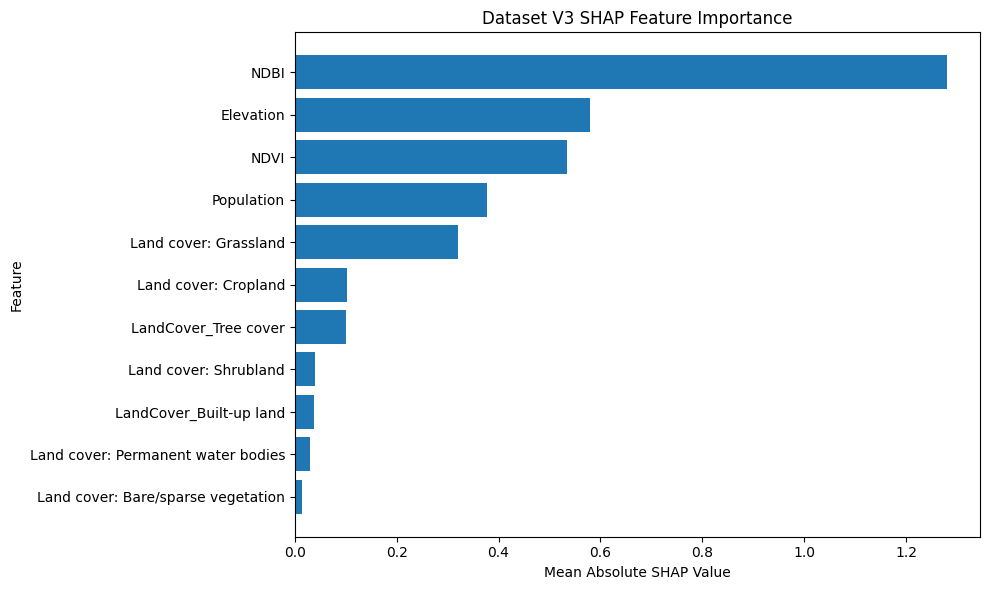

Saved:
outputs/reports/shap_feature_importance_v3.csv
outputs/plots/shap_feature_importance_v3.png


In [10]:
os.makedirs("../outputs/reports", exist_ok=True)
os.makedirs("../outputs/plots", exist_ok=True)

# Fill any unmapped feature names with their original feature name
shap_importance_v3["Readable_Feature"] = (
    shap_importance_v3["Readable_Feature"]
    .fillna(shap_importance_v3["Feature"])
)

# Save SHAP importance table
shap_importance_v3.to_csv(
    "../outputs/reports/shap_feature_importance_v3.csv",
    index=False
)

# Create and save SHAP importance chart
plt.figure(figsize=(10, 6))

plt.barh(
    shap_importance_v3["Readable_Feature"].astype(str),
    shap_importance_v3["Mean_Absolute_SHAP"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Dataset V3 SHAP Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    "../outputs/plots/shap_feature_importance_v3.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print("outputs/reports/shap_feature_importance_v3.csv")
print("outputs/plots/shap_feature_importance_v3.png")

## Dataset V3 Explainable AI Conclusion

SHAP analysis was used to quantify how each Dataset V3 feature contributed to final XGBoost predictions.

The interpretation should focus on the SHAP importance ranking and feature-effect plots generated above. LandCover variables represent categorical surface classes and should be interpreted as class-specific effects relative to the remaining land-cover classes.

The analysis supports transparent heat-driver interpretation. It does not by itself prove causation, and intervention claims should be validated through the scenario-simulation workflow.